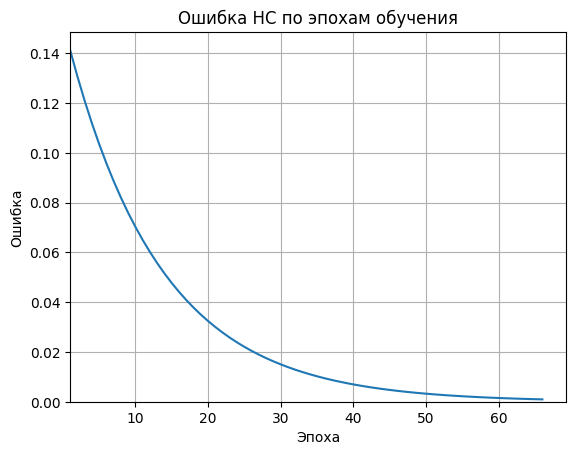

Обучение завершено за 66 эпох с ошибкой 0.000943
Выход сети после обучения: [np.float64(-0.0993), np.float64(-0.0993)]
Целевой вектор: [-0.1, -0.1]


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Функция активации (статическая)
class f_net:
    def f(net):
        return (1. - np.exp(-net)) / (1. + np.exp(-net))

    def out(net):
        return f_net.f(net)

    def df(net):
        return 0.5 * (1 - f_net.f(net)**2)


# Один нейрон
class one_neuron:
    def __init__(self, w_vector_size, net_function):
        self.w_vector = [0.0] * w_vector_size   # начальные веса нулевые
        self.net_function = net_function        # класс функции активации

    def out(self, in_vector):
        net = sum(self.w_vector[i] * in_vector[i] for i in range(len(self.w_vector)))
        return self.net_function.out(net)

    def count_delta(self, in_vector, multiplier):
        net = sum(self.w_vector[i] * in_vector[i] for i in range(len(self.w_vector)))
        return self.net_function.df(net) * multiplier

    def update_w_vector(self, in_vector, delta, norm):
        for i in range(len(self.w_vector)):
            self.w_vector[i] += norm * in_vector[i] * delta


# Нейронная сеть
class bp_nn:
    def __init__(self, N, J, M, net_function):
        self.N = N          # число входов (без смещения)
        self.J = J          # число скрытых нейронов
        self.M = M          # число выходов
        self.net_function = net_function
        self.educated = False

        # Скрытый слой (J нейронов) – каждый принимает N+1 вход (включая смещение)
        self.J_neurons = [one_neuron(self.N + 1, self.net_function) for _ in range(self.J)]

        # Выходной слой (M нейронов) – каждый принимает J+1 вход (включая смещение)
        self.M_neurons = [one_neuron(self.J + 1, self.net_function) for _ in range(self.M)]

    def educate(self, x_vector, t_vector, edu_norm=0.1, max_error=0.001, max_ages=40000,
                show_plot=False, file_name='nn_edu.txt'):
        # Проверка размеров
        if len(x_vector) != self.N + 1:
            print(f"Неверный размер входного вектора: {len(x_vector)}, ожидалось {self.N+1}")
            return
        if len(t_vector) != self.M:
            print(f"Неверный размер выходного вектора: {len(t_vector)}, ожидалось {self.M}")
            return

        E_array = []
        with open(file_name, 'w') as f:
            f.write("-" * 80 + "\n")

            age = 0
            while age < max_ages:
                age += 1

                # ----- Прямой проход -----
                # Выходы скрытого слоя
                J_vector = [neuron.out(x_vector) for neuron in self.J_neurons]

                # Вход для выходного слоя (со смещением)
                in_M_vector = [1.0] + J_vector

                out_vector = [neuron.out(in_M_vector) for neuron in self.M_neurons]

                # Ошибка
                error = np.sqrt(sum((t_vector[i] - out_vector[i])**2 for i in range(self.M)))
                E_array.append(error)

                # Запись в файл (по желанию)
                f.write(f"Age: {age}\n")
                f.write("W vectors J:\n")
                for neuron in self.J_neurons:
                    f.write(f"{neuron.w_vector}\n")
                f.write("W vectors M:\n")
                for neuron in self.M_neurons:
                    f.write(f"{neuron.w_vector}\n")
                f.write(f"Out vector: {out_vector}\n")
                f.write(f"Error: {error}\n")
                f.write("-" * 80 + "\n")

                if error <= max_error:
                    self.educated = True
                    break

                # ----- Обратный проход (расчёт дельт) -----
                # Выходной слой
                delta_M = []
                for m in range(self.M):
                    multiplier = t_vector[m] - out_vector[m]
                    delta_M.append(self.M_neurons[m].count_delta(in_M_vector, multiplier))

                # Скрытый слой
                delta_J = []
                for j in range(self.J):
                    multiplier = 0.0
                    for m in range(self.M):
                        multiplier += delta_M[m] * self.M_neurons[m].w_vector[j]   # веса от j-го скрытого к m-му выходному
                    delta_J.append(self.J_neurons[j].count_delta(x_vector, multiplier))

                # ----- Коррекция весов -----
                # Скрытый слой
                for j in range(self.J):
                    self.J_neurons[j].update_w_vector(x_vector, delta_J[j], edu_norm)
                # Выходной слой
                for m in range(self.M):
                    self.M_neurons[m].update_w_vector(in_M_vector, delta_M[m], edu_norm)

        if show_plot:
            plt.plot(range(1, age+1), E_array)
            plt.xlabel("Эпоха")
            plt.xlim(left=1)
            plt.ylabel("Ошибка")
            plt.ylim(bottom=0)
            plt.title("Ошибка НС по эпохам обучения")
            plt.grid()
            plt.show()

        self.error = error
        self.ages = age



# Запуск для варианта 16
if __name__ == "__main__":
    # Архитектура 2-1-2
    N = 2   # число входных сигналов (без смещения)
    J = 1   # число скрытых нейронов
    M = 2   # число выходов

    # Входной вектор (x0=1, x1=2, x2=1)
    x_vector = [1.0, 2.0, 1.0]   # длина N+1 = 3
    # Целевой вектор
    t_vector = [-0.1, -0.1]       # длина M = 2

    lr = 0.3                     # норма обучения (по заданию можно 1)
    max_err = 0.001               # требуемая точность

    # Создание сети
    nn = bp_nn(N, J, M, f_net)

    # Обучение
    nn.educate(x_vector, t_vector, edu_norm=lr, max_error=max_err,
               show_plot=True, file_name='variant16_log.txt')

    # Вывод результата
    if nn.educated:
        print(f"Обучение завершено за {nn.ages} эпох с ошибкой {nn.error:.6f}")
        # Проверка выхода после обучения
        J_vector = [neuron.out(x_vector) for neuron in nn.J_neurons]
        in_M_vector = [1.0] + J_vector
        final_out = [neuron.out(in_M_vector) for neuron in nn.M_neurons]
        print("Выход сети после обучения:", [round(x, 4) for x in final_out])
        print("Целевой вектор:", t_vector)
    else:
        print(f"Обучение не достигло ошибки {max_err} за {nn.ages} эпох. Текущая ошибка: {nn.error:.6f}")